In [ ]:
# Start venv
# python3 -m venv myenv
# source myenv/bin/activate


In [3]:
%pip install insightface opencv-python numpy onnxruntime
%pip install mtcnn
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import cv2
import numpy as np
import insightface
from insightface.app import FaceAnalysis
import matplotlib.pyplot as plt
from mtcnn import MTCNN
import math
# Initialize MTCNN detector
mtcnn = MTCNN()

# Initialize InsightFace (ArcFace) model
app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(320, 320))

def extract_embedding(image_path,temp,printimage=False):
    """Detect faces using MTCNN & extract embeddings using InsightFace"""
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Error: Couldn't load '{image_path}'")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect faces using MTCNN
    faces = mtcnn.detect_faces(img_rgb)
    
    if len(faces) == 0:
        print(f"❌ No face detected in {image_path}")
        return None

    embeddings = []
    count=0
    
    num_faces = len(faces)
    rows = min(5, num_faces)  # Use up to 5 rows
    cols = math.ceil(num_faces / rows)  # Calculate columns dynamically
    if printimage:
        fig, ax = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        ax = np.array(ax).reshape(rows, cols)  # Ensure it's a 2D array
    
    for idx, face in enumerate(faces):
        x, y, w, h = face["box"]
        x2, y2 = x + w, y + h
    
        # Draw bounding box
        cv2.rectangle(img_rgb, (x, y), (x2, y2), (0, 255, 0), 2)
    
        # Crop detected face
        face_crop = img[y:y2, x:x2]
    
        # Extract embedding using InsightFace
        detected_faces = app.get(face_crop)
    
        if len(detected_faces) > 0:
            embedding = detected_faces[0].normed_embedding
            embeddings.append(embedding)
            temp.append(face_crop)
    
            if printimage:
            # Determine subplot position
                row, col = divmod(idx, cols)
                ax[row, col].imshow(face_crop)
                ax[row, col].set_title(f"Face {idx + 1}")
                ax[row, col].axis("off")
    
    # plt.tight_layout()
    # plt.show()
    
    # Show image with bounding boxes
    # plt.figure(figsize=(8, 6))
    # plt.imshow(img_rgb)
    # plt.axis("off")
    # plt.title(f"Detected Faces in {image_path}")
    # plt.show()


    # x, y, w, h = faces[0]["box"]
    # x2, y2 = x + w, y + h
    # face_crop = img[y:y2, x:x2]
    # plt.figure(figsize=(8, 6))
    # plt.imshow(face_crop)
    # plt.axis("off")
    # plt.show()
    
    return embeddings


2025-03-30 21:45:24.471967: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-30 21:45:24.485100: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-30 21:45:24.583664: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-30 21:45:24.672548: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743371124.749308     984 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743371124.77

download_path: /home/ayush/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:25<00:00, 11233.79KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ayush/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ayush/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ayush/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ayush/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ayush/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det

In [5]:
import os
import pickle
import numpy as np

REFERENCE_PATH = "/home/ayush/DSP_Project/faces"

def create_composite_embeddings():
    reference_embeddings = {}

    for person in os.listdir(REFERENCE_PATH):
        person_path = os.path.join(REFERENCE_PATH, person)
        if not os.path.isdir(person_path):
            continue
        
        embeddings = []
        for img_file in os.listdir(person_path):
            image_path = os.path.join(person_path, img_file)
            temp2 = []
            embedding = extract_embedding(image_path, temp2)

            if embedding is not None:
                embedding = np.array(embedding).squeeze()  # Ensures correct shape
                embeddings.append(embedding)

        if embeddings:
            try:
                composite_embedding = np.mean(np.vstack(embeddings), axis=0)
                reference_embeddings[person] = composite_embedding
                print(f"✅ Composite embedding generated for {person}")
            except ValueError as e:
                print(f"❌ Error merging embeddings for {person}: {e}")

    # Save embeddings to file
    with open("reference_embeddings.pkl", "wb") as f:
        pickle.dump(reference_embeddings, f)

    print("✅ All reference embeddings saved successfully.")

In [44]:
create_composite_embeddings()

✅ Composite embedding generated for Hemant
✅ Composite embedding generated for Arshad Amaan
✅ Composite embedding generated for Sreekar
✅ Composite embedding generated for Vivek
✅ Composite embedding generated for Krutarth
✅ Composite embedding generated for Ashish
✅ Composite embedding generated for Aniruddha
✅ Composite embedding generated for Nishant
✅ Composite embedding generated for Sameer
✅ Composite embedding generated for Ayush Gupta
✅ Composite embedding generated for Rohan Rudra
✅ Composite embedding generated for Aditya Abhilash
✅ Composite embedding generated for Rachit
✅ Composite embedding generated for Ayush Agrawal
✅ All reference embeddings saved successfully.


In [5]:
import pickle
import numpy as np

# Load reference embeddings
with open("reference_embeddings.pkl", "rb") as f:
    reference_embeddings = pickle.load(f)

# Convert reference embeddings (M×512) to a NumPy array of shape (M, 512)
persons = list(reference_embeddings.keys())  # List of person names
ref_matrix = np.array([reference_embeddings[person] for person in persons])  # Shape: (M, 512)

# Function to identify persons based on current embeddings
def identify_person(group_embeddings, threshold=0.5):
    group_embeddings = np.array(group_embeddings)  # Shape: (N, 512)

    # Invert current embeddings (N×512 → 512×N)
    group_matrix = group_embeddings.T  # Shape: (512, N)

    # Compute similarity using matrix multiplication (M×512) · (512×N) = (M×N)
    similarity_matrix = np.dot(ref_matrix, group_matrix)  # Shape: (M, N)

    # Normalize similarity scores (optional)
    similarity_matrix = (similarity_matrix - similarity_matrix.min()) / (similarity_matrix.max() - similarity_matrix.min())

    match_results = []

    # Iterate through each row (M) — checking reference persons
    for i, similarities in enumerate(similarity_matrix):
        best_idx = np.argmax(similarities)  # Index of max similarity
        best_score = similarities[best_idx]  # Max similarity score

        if best_score > threshold:  # Check threshold
            match_results.append((persons[i], best_idx, best_score))

    return match_results



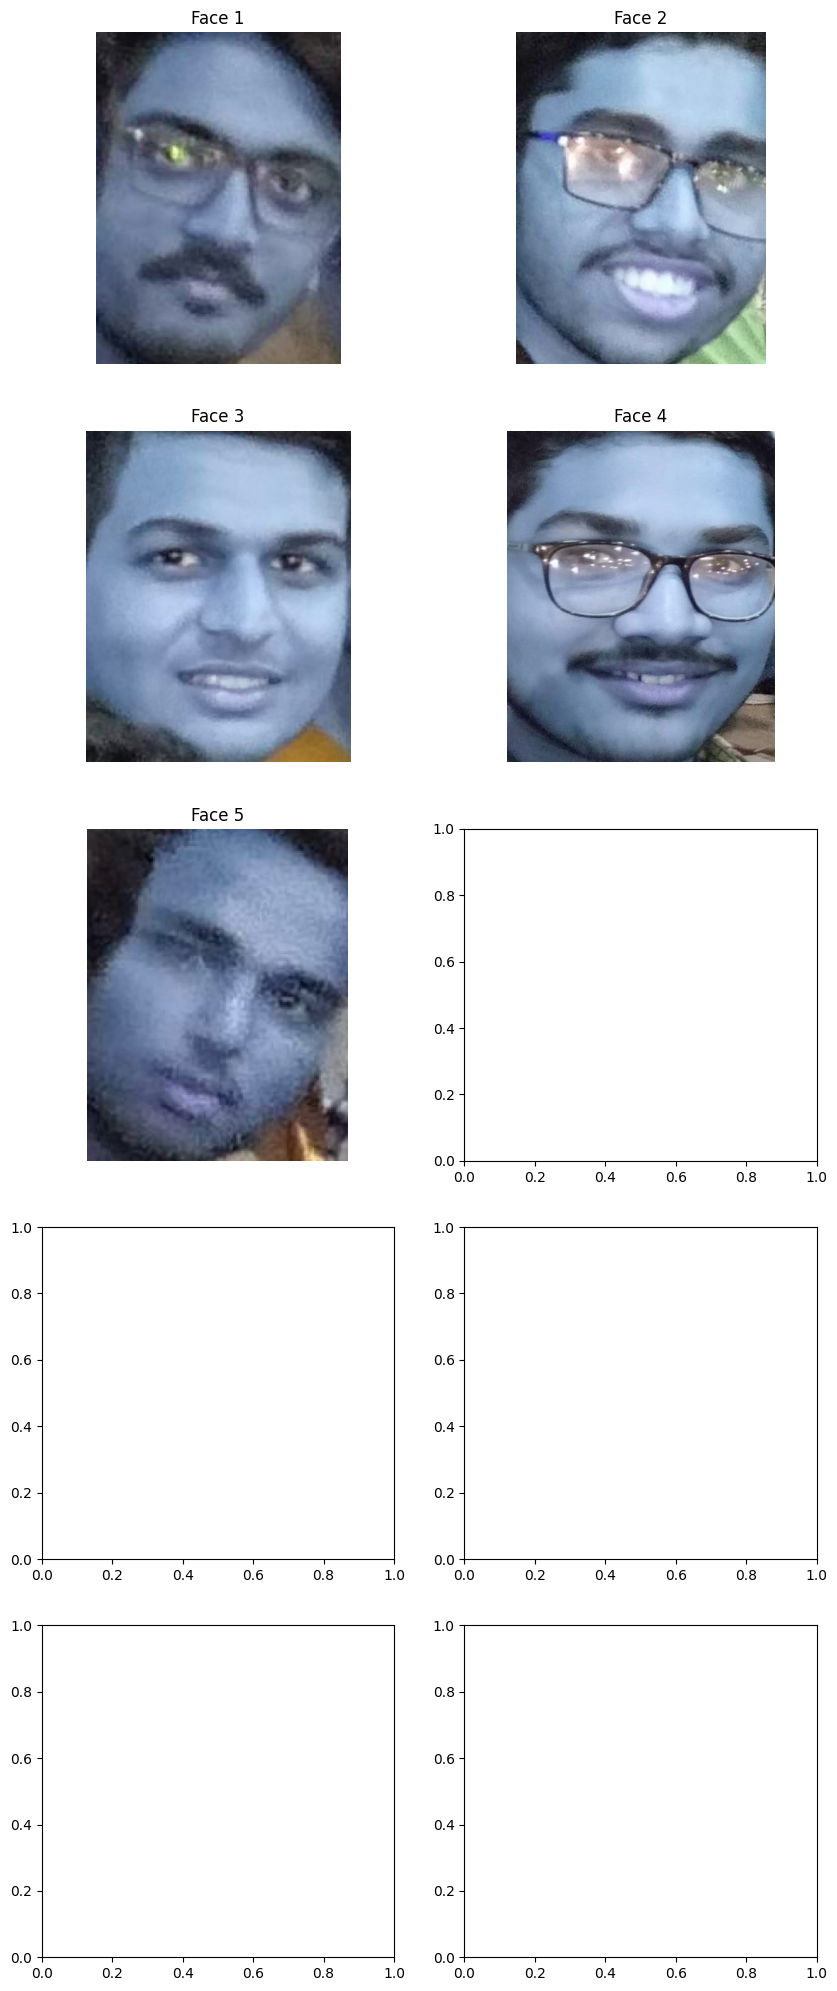

In [6]:
temp2=[]
embedding_vectors2 = extract_embedding("/home/ayush/DSP_Project/test_images/8all.jpg",temp2,True)

In [7]:
print(len(embedding_vectors2))


5


In [13]:
matches = identify_person(embedding_vectors2, 0.6)

# Sort matches by confidence score in descending order
matches.sort(key=lambda x: x[2], reverse=True)

# Print results
for idx, person, score in matches:
    print(f"Face {idx} matches {person} with confidence {score:.2f}")

Face Krutarth matches 1 with confidence 1.00
Face Ayush Agrawal matches 0 with confidence 0.97
Face Ashish matches 2 with confidence 0.96
Face Ayush Gupta matches 3 with confidence 0.86
